In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cuda


In [ ]:
df = pd.read_csv("/content/IMDB-Dataset.csv", on_bad_lines="skip").head(10000)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(10000, 2)

In [ ]:
# Improved text cleaning function
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters
    text = text.lower().strip()
    return text

In [ ]:
df = df.dropna()
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'].astype(str))

df['cleaned_review'] = df['review'].apply(clean_text)
df['review_split'] = df['cleaned_review'].str.split()

In [ ]:
df.head()

,review,sentiment,cleaned_review,review_split
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


In [ ]:
all_words = [word for review in df['review_split'] for word in review]
vocab = sorted(list(set(all_words)))
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
vocab_size = len(word_to_idx) + 1

max_seq_len = 200

In [ ]:
word_to_idx

{'a': 1,
 'aa': 2,
 'aaa': 3,
 'aaaarrgh': 4,
 'aaahthe': 5,
 'aaall': 6,
 'aaargh': 7,
 'aaaugh': 8,
 'aadmittedly': 9,
 'aag': 10,
 'aage': 11,
 'aaghh': 12,
 'aahed': 13,
 'aaip': 14,
 'aak': 15,
 'aaliyah': 16,
 'aaliyahs': 17,
 'aames': 18,
 'aamir': 19,
 'aamirs': 20,
 'aankhen': 21,
 'aap': 22,
 'aapkey': 23,
 'aardman': 24,
 'aaron': 25,
 'aarons': 26,
 'aarp': 27,
 'aashok': 28,
 'aasize': 29,
 'aatish': 30,
 'aavjo': 31,
 'aawip': 32,
 'ab': 33,
 'aback': 34,
 'abandon': 35,
 'abandoned': 36,
 'abandoning': 37,
 'abandonment': 38,
 'abandons': 39,
 'abashed': 40,
 'abba': 41,
 'abbas': 42,
 'abbey': 43,
 'abbeys': 44,
 'abbeythe': 45,
 'abbie': 46,
 'abbot': 47,
 'abbott': 48,
 'abbotts': 49,
 'abbottwe': 50,
 'abbreviate': 51,
 'abbreviated': 52,
 'abby': 53,
 'abbys': 54,
 'abc': 55,
 'abccom': 56,
 'abcrelease': 57,
 'abcs': 58,
 'abdalla': 59,
 'abdic': 60,
 'abdomen': 61,
 'abduct': 62,
 'abducted': 63,
 'abductee': 64,
 'abducting': 65,
 'abduction': 66,
 'abductionman'

In [ ]:
def encode_safe(text_list):
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in text_list]
    encoded = encoded[:max_seq_len]
    return encoded + [0] * (max_seq_len - len(encoded))

df['encoded_review'] = df['review_split'].apply(encode_safe)
df.head()

,review,sentiment,cleaned_review,review_split,encoded_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[50026, 49602, 70967, 50699, 59166, 31424, 443..."
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[1, 79128, 41042, 55537, 70967, 25384, 70366, ..."
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[34176, 71638, 71485, 77299, 1, 79128, 77551, ..."
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[5659, 71262, 1, 24311, 78277, 1, 41042, 8317,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[53033, 43484, 41627, 34836, 70967, 72001, 496..."


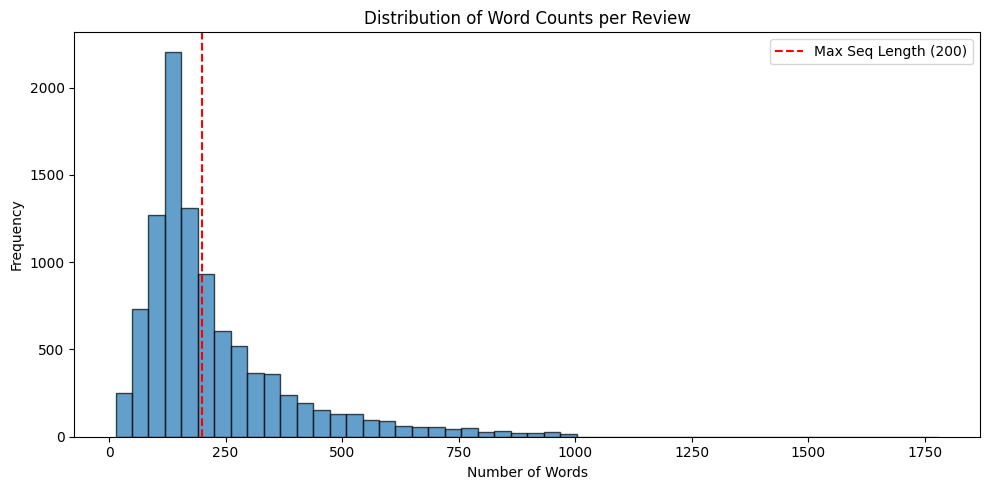

In [ ]:
# ============ VISUALIZATION 1: Histogram of Word Counts ============
df['word_count'] = df['review_split'].apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts per Review')
plt.axvline(x=max_seq_len, color='red', linestyle='--', label=f'Max Seq Length ({max_seq_len})')
plt.legend()
plt.tight_layout()
plt.show()

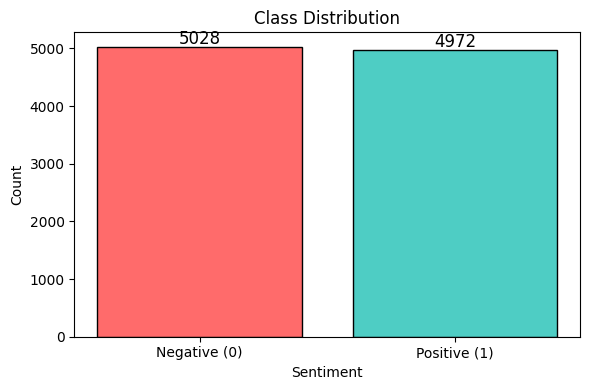

In [ ]:
# ============ VISUALIZATION 2: Class Balance ============
plt.figure(figsize=(6, 4))
sentiment_counts = df['sentiment'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
bars = plt.bar(['Negative (0)', 'Positive (1)'], sentiment_counts.values, color=colors, edgecolor='black')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Class Distribution')
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

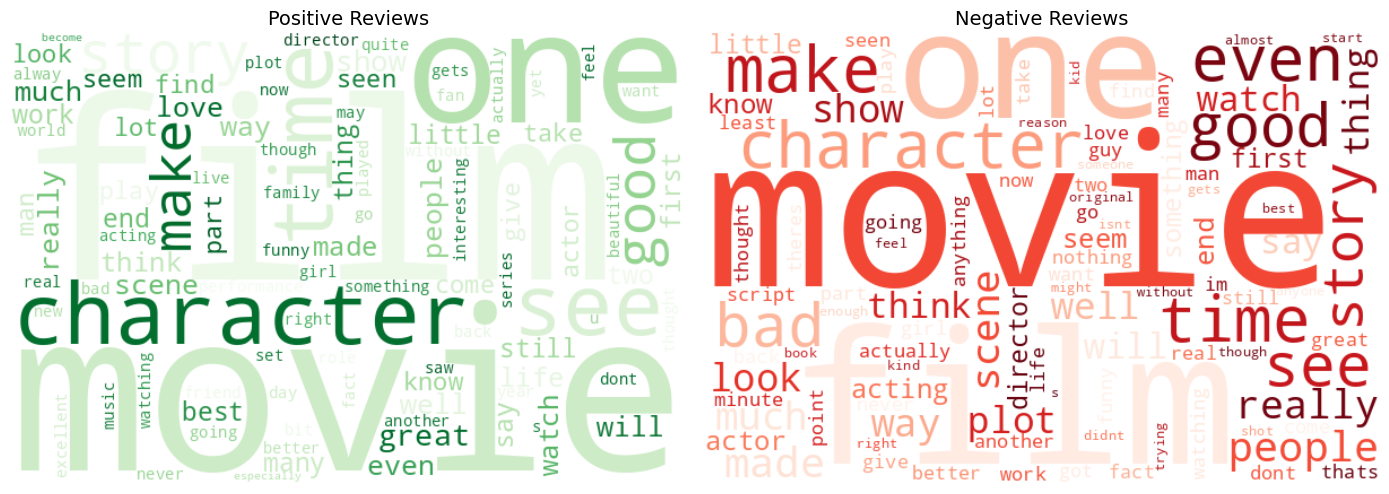

In [ ]:
# ============ VISUALIZATION 3: Word Clouds ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive reviews word cloud
positive_words = ' '.join(df[df['sentiment'] == 1]['cleaned_review'])
wc_pos = WordCloud(width=600, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14)
axes[0].axis('off')

# Negative reviews word cloud
negative_words = ' '.join(df[df['sentiment'] == 0]['cleaned_review'])
wc_neg = WordCloud(width=600, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        # We use the actual column names from our dataframe
        self.texts = list(data['encoded_review'])
        self.labels = list(data['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

train_loader = DataLoader(SentimentDataset(train_data), batch_size=32, shuffle=True)
test_loader = DataLoader(SentimentDataset(test_data), batch_size=32, shuffle=False)

In [ ]:
for x, y in train_loader:
    print(x.shape, y.shape)

    break

torch.Size([32, 200]) torch.Size([32])


In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.5):
        super(SentimentRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        # Correctly initialize h0 with the number of layers from self.rnn
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(embedded, h0)
        # out.shape = (batch_size, seq_len, hidden_size)
        out = self.dropout(out[:, -1, :])  # Dropout before FC layer
        return self.fc(out)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Starting Training...")
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Store metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(100 * train_correct / train_total)
        history['val_acc'].append(100 * val_correct / val_total)

        duration = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}% | {duration:.1f}s")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}! Val loss hasn't improved for {patience} epochs.")
                break

    return history

In [ ]:
model = SentimentRNN(vocab_size, embed_size=128, hidden_size=128, output_size=2, dropout=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
rnn_history = train_model(model, train_loader, test_loader)

Starting Training...
Epoch 1/15 | Train Loss: 0.7034 | Val Loss: 0.6958 | Train Acc: 49.71% | Val Acc: 49.65% | 2.8s
Epoch 2/15 | Train Loss: 0.6942 | Val Loss: 0.6942 | Train Acc: 50.91% | Val Acc: 49.75% | 2.1s
Epoch 3/15 | Train Loss: 0.6940 | Val Loss: 0.6958 | Train Acc: 51.09% | Val Acc: 50.05% | 2.2s
Epoch 4/15 | Train Loss: 0.6876 | Val Loss: 0.7012 | Train Acc: 53.75% | Val Acc: 50.20% | 1.9s
Epoch 5/15 | Train Loss: 0.6888 | Val Loss: 0.7004 | Train Acc: 52.71% | Val Acc: 48.75% | 1.9s
Epoch 6/15 | Train Loss: 0.6838 | Val Loss: 0.7035 | Train Acc: 53.70% | Val Acc: 49.10% | 1.9s
Epoch 7/15 | Train Loss: 0.6832 | Val Loss: 0.7047 | Train Acc: 53.73% | Val Acc: 49.40% | 1.9s

Early stopping at epoch 7! Val loss hasn't improved for 5 epochs.


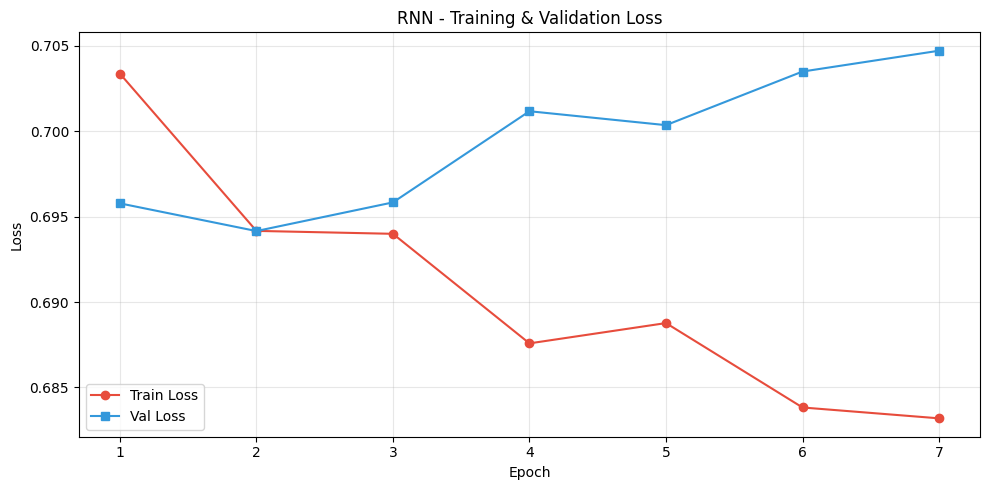

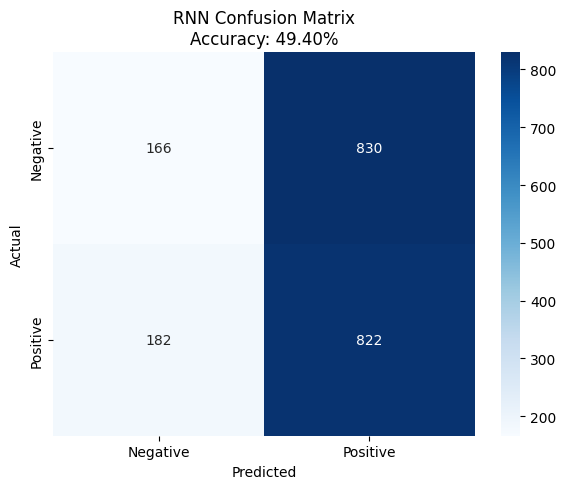

In [ ]:
# ============ 4. RNN Train and Val Loss Curve ============
epochs_range = range(1, len(rnn_history['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, rnn_history['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, rnn_history['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ 5. RNN Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'RNN Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(text, model, word_to_idx, max_len=100):
    model.eval()

    tokens = text.lower().split()

    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in tokens]

    # 3. Pad or Truncate
    encoded = encoded[:max_len]
    padded = encoded + [0] * (max_len - len(encoded))

    input_tensor = torch.tensor([padded], dtype=torch.long).to(device)


    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        _, predicted = torch.max(output, 1)

    sentiment = "Positive" if predicted.item() == 1 else "Negative"
    confidence = probabilities[0][predicted.item()].item()

    return sentiment, confidence



In [ ]:
examples = [
    "This movie was bad",
    "What a waste of time. The acting was terrible and the plot made no sense.",
    "It was okay, but I wouldn't watch it again.",
    "The cinematography was beautiful even if the story was a bit slow."
]

print("\n--- Model Testing ---")
for text in examples:
    label, conf = predict_sentiment(text, model, word_to_idx)
    print(f"Review: {text}")
    print(f"Prediction: {label} ({conf*100:.1f}% confidence)\n")


--- Model Testing ---
Review: This movie was bad
Prediction: Positive (54.8% confidence)

Review: What a waste of time. The acting was terrible and the plot made no sense.
Prediction: Positive (54.8% confidence)

Review: It was okay, but I wouldn't watch it again.
Prediction: Positive (54.8% confidence)

Review: The cinematography was beautiful even if the story was a bit slow.
Prediction: Positive (54.8% confidence)



In [ ]:
# 1. The Upgraded LSTM Class
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # LSTM handles long-term memory; dropout prevents memorizing noise
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, verbose=False): # Added verbose back to match your training function
        if verbose: print(f"Input Shape: {x.shape}")

        embedded = self.embedding(x)

        # out shape: [batch, seq_len, hidden_size]
        out, (hn, cn) = self.lstm(embedded)

        last_step = out[:, -1, :]

        last_step = self.dropout(last_step)

        return self.fc(last_step)

# 2. Re-Initialize with LSTM
model = SentimentLSTM(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
lstm_history = train_model(model, train_loader, test_loader, epochs=15)

Starting Training...
Epoch 1/15 | Train Loss: 0.6939 | Val Loss: 0.6937 | Train Acc: 50.56% | Val Acc: 50.80% | 2.7s
Epoch 2/15 | Train Loss: 0.6885 | Val Loss: 0.6986 | Train Acc: 53.71% | Val Acc: 48.15% | 2.7s
Epoch 3/15 | Train Loss: 0.6753 | Val Loss: 0.7228 | Train Acc: 54.92% | Val Acc: 50.95% | 2.6s
Epoch 4/15 | Train Loss: 0.6251 | Val Loss: 0.7073 | Train Acc: 59.83% | Val Acc: 55.40% | 2.6s
Epoch 5/15 | Train Loss: 0.5329 | Val Loss: 0.7389 | Train Acc: 67.11% | Val Acc: 65.50% | 2.6s
Epoch 6/15 | Train Loss: 0.3909 | Val Loss: 0.7860 | Train Acc: 82.22% | Val Acc: 72.10% | 2.8s

Early stopping at epoch 6! Val loss hasn't improved for 5 epochs.


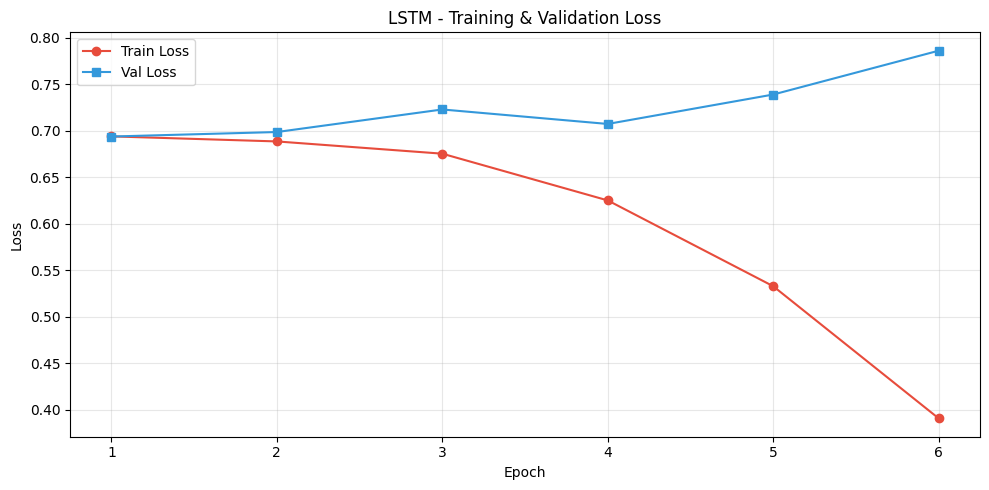

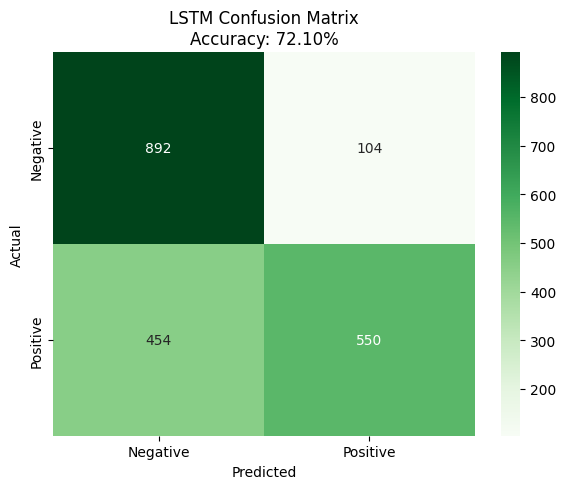

In [ ]:
# ============ LSTM Train and Val Loss Curve ============
epochs_range = range(1, len(lstm_history['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, lstm_history['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, lstm_history['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ LSTM Confusion Matrix ============
y_true, y_pred = get_predictions(model, test_loader)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'LSTM Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [ ]:

for text in examples:
    label, conf = predict_sentiment(text, model, word_to_idx)
    print(f"Review: {text}")
    print(f"Prediction: {label} ({conf*100:.1f}% confidence)\n")

Review: This movie was bad
Prediction: Negative (73.6% confidence)

Review: What a waste of time. The acting was terrible and the plot made no sense.
Prediction: Negative (86.4% confidence)

Review: It was okay, but I wouldn't watch it again.
Prediction: Positive (75.1% confidence)

Review: The cinematography was beautiful even if the story was a bit slow.
Prediction: Negative (51.8% confidence)



In [ ]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # GRU is similar to LSTM but faster and often just as effective
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.3)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, verbose=False):
        if verbose: print(f"Input Shape: {x.shape}")

        embedded = self.embedding(x)

        out, hn = self.gru(embedded)

        last_step = out[:, -1, :]

        last_step = self.dropout(last_step)

        return self.fc(last_step)

model = SentimentGRU(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# GRU usually converges faster than LSTM
gru_history = train_model(model, train_loader, test_loader, epochs=15)

Starting Training...
Epoch 1/15 | Train Loss: 0.7021 | Val Loss: 0.6935 | Train Acc: 50.34% | Val Acc: 51.65% | 2.2s
Epoch 2/15 | Train Loss: 0.6910 | Val Loss: 0.6916 | Train Acc: 53.61% | Val Acc: 52.20% | 2.2s
Epoch 3/15 | Train Loss: 0.6714 | Val Loss: 0.6647 | Train Acc: 57.59% | Val Acc: 60.25% | 2.2s
Epoch 4/15 | Train Loss: 0.5367 | Val Loss: 0.5412 | Train Acc: 74.03% | Val Acc: 73.95% | 2.2s
Epoch 5/15 | Train Loss: 0.3262 | Val Loss: 0.5486 | Train Acc: 86.69% | Val Acc: 77.50% | 2.4s
Epoch 6/15 | Train Loss: 0.1540 | Val Loss: 0.5667 | Train Acc: 94.40% | Val Acc: 79.25% | 2.2s
Epoch 7/15 | Train Loss: 0.0625 | Val Loss: 0.7211 | Train Acc: 97.96% | Val Acc: 78.70% | 2.2s
Epoch 8/15 | Train Loss: 0.0274 | Val Loss: 0.9346 | Train Acc: 99.33% | Val Acc: 79.35% | 2.2s
Epoch 9/15 | Train Loss: 0.0162 | Val Loss: 1.0227 | Train Acc: 99.49% | Val Acc: 79.05% | 2.2s

Early stopping at epoch 9! Val loss hasn't improved for 5 epochs.


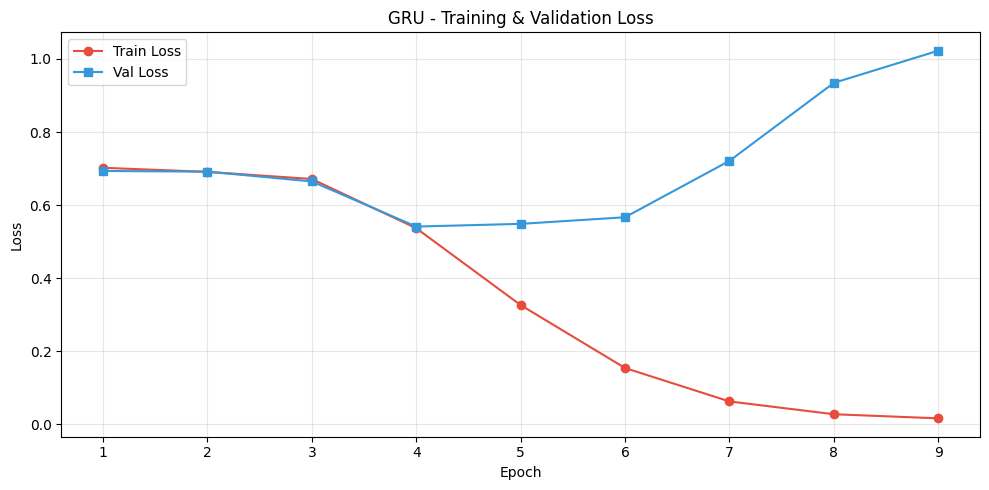

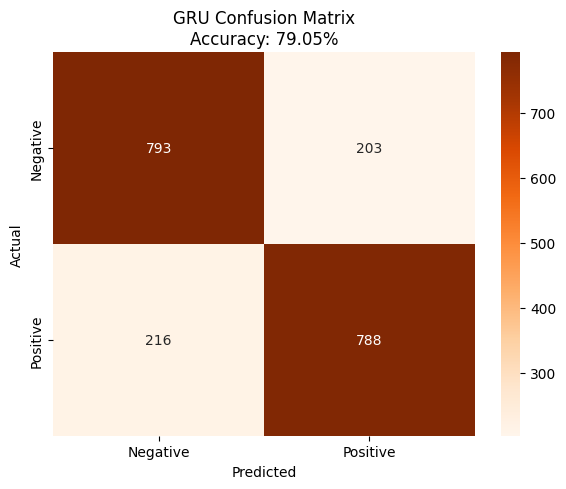

In [ ]:
# ============ GRU Train and Val Loss Curve ============
epochs_range = range(1, len(gru_history['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, gru_history['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, gru_history['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ GRU Confusion Matrix ============
y_true, y_pred = get_predictions(model, test_loader)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'GRU Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Model Testing ---")
for text in examples:
    label, conf = predict_sentiment(text, model, word_to_idx)
    print(f"Review: {text}")
    print(f"Prediction: {label} ({conf*100:.1f}% confidence)\n")


--- Model Testing ---
Review: This movie was bad
Prediction: Negative (100.0% confidence)

Review: What a waste of time. The acting was terrible and the plot made no sense.
Prediction: Negative (100.0% confidence)

Review: It was okay, but I wouldn't watch it again.
Prediction: Positive (69.5% confidence)

Review: The cinematography was beautiful even if the story was a bit slow.
Prediction: Negative (100.0% confidence)



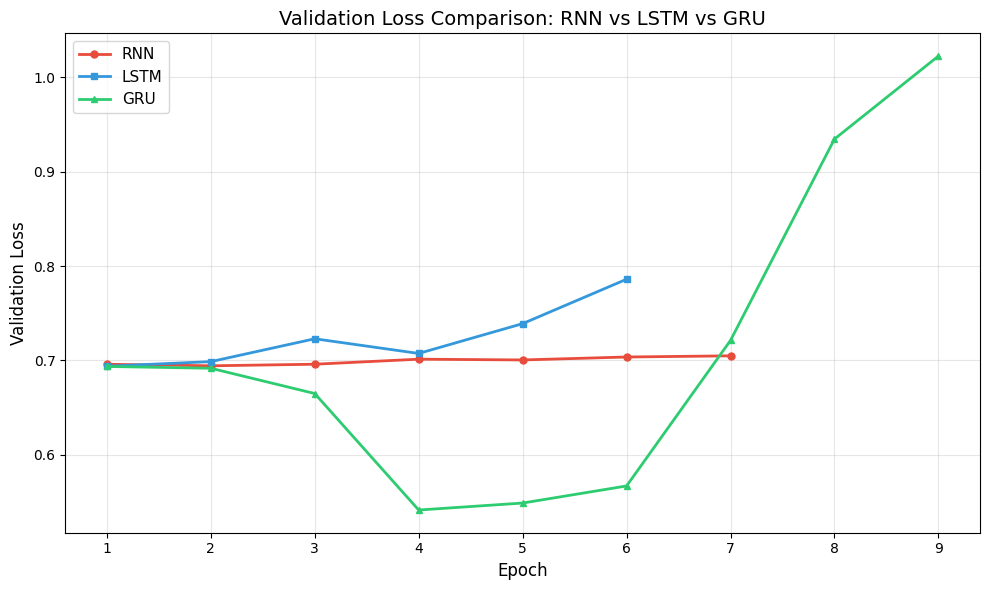


FINAL MODEL COMPARISON
RNN  | Final Val Accuracy: 49.40%
LSTM | Final Val Accuracy: 72.10%
GRU  | Final Val Accuracy: 79.05%


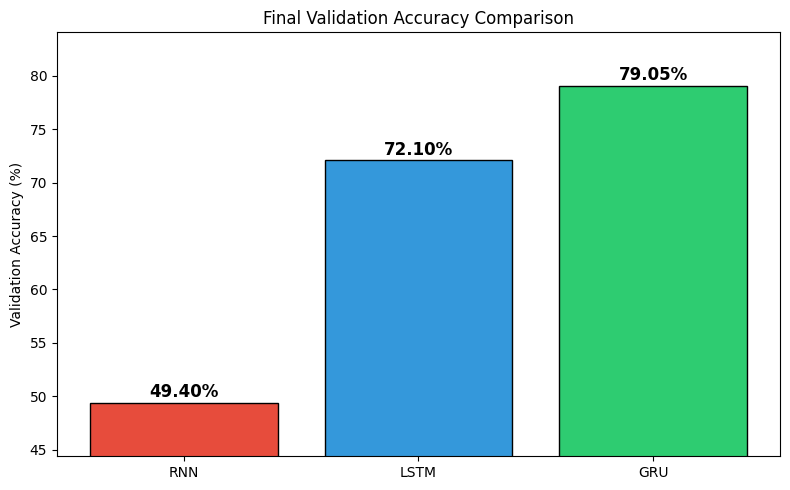

In [ ]:
# ============ Combined Validation Loss Curve ============
plt.figure(figsize=(10, 6))

# Make sure all histories have same length for fair comparison
plt.plot(range(1, len(rnn_history['val_loss']) + 1), rnn_history['val_loss'],
         label='RNN', color='#e74c3c', linewidth=2, marker='o', markersize=5)
plt.plot(range(1, len(lstm_history['val_loss']) + 1), lstm_history['val_loss'],
         label='LSTM', color='#3498db', linewidth=2, marker='s', markersize=5)
plt.plot(range(1, len(gru_history['val_loss']) + 1), gru_history['val_loss'],
         label='GRU', color='#2ecc71', linewidth=2, marker='^', markersize=5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Validation Loss Comparison: RNN vs LSTM vs GRU', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ Final Accuracy Comparison ============
print("\n" + "="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
print(f"RNN  | Final Val Accuracy: {rnn_history['val_acc'][-1]:.2f}%")
print(f"LSTM | Final Val Accuracy: {lstm_history['val_acc'][-1]:.2f}%")
print(f"GRU  | Final Val Accuracy: {gru_history['val_acc'][-1]:.2f}%")
print("="*50)

# ============ Combined Accuracy Comparison Bar Chart ============
plt.figure(figsize=(8, 5))
models_names = ['RNN', 'LSTM', 'GRU']
final_accs = [rnn_history['val_acc'][-1], lstm_history['val_acc'][-1], gru_history['val_acc'][-1]]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = plt.bar(models_names, final_accs, color=colors, edgecolor='black')
plt.ylabel('Validation Accuracy (%)')
plt.title('Final Validation Accuracy Comparison')
plt.ylim(min(final_accs) - 5, max(final_accs) + 5)

for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### We have trained three models (RNN, LSTM, GRU) for sentiment analysis, but they have problems — RNN is underfitting (flat validation loss, not learning enough) while LSTM and GRU are overfitting (validation loss explodes after epoch 4-5). Your task is divided into two phases.
### In Phase 1, fix all three architectures by experimenting with techniques like adding dropout at multiple positions, reducing model capacity (smaller hidden_size, fewer layers), implementing gradient clipping using clip_grad_norm_(), adding learning rate scheduler (ReduceLROnPlateau), and early stopping — your goal is to achieve stable, decreasing validation loss for all models.
### In Phase 2, once models are fixed, combine them into an ensemble system by implementing three voting strategies: hard voting (majority class wins), soft voting (average softmax probabilities), and weighted voting (weight each model by its validation accuracy).

# Phase 1

# RNN

In [ ]:
class SentimentRNN2(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.2):
        super(SentimentRNN2, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        # Correctly initialize h0 with the number of layers from self.rnn
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(embedded, h0)
        # out.shape = (batch_size, seq_len, hidden_size)
        out = self.dropout(out[:, -1, :])  # Dropout before FC layer
        return self.fc(out)

# Decreased embedding size (128->64), dropout(0.5->0.3)


In [ ]:
model2 = SentimentRNN2(vocab_size, embed_size=64, hidden_size=128, output_size=2, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.0005, weight_decay=1e-4)
rnn_history2 = train_model(model2, train_loader, test_loader)

Starting Training...
Epoch 1/15 | Train Loss: 0.6986 | Val Loss: 0.6969 | Train Acc: 50.54% | Val Acc: 49.30% | 1.4s
Epoch 2/15 | Train Loss: 0.6930 | Val Loss: 0.6963 | Train Acc: 51.96% | Val Acc: 51.50% | 1.7s
Epoch 3/15 | Train Loss: 0.6901 | Val Loss: 0.7051 | Train Acc: 53.01% | Val Acc: 49.60% | 1.6s
Epoch 4/15 | Train Loss: 0.6875 | Val Loss: 0.7015 | Train Acc: 52.99% | Val Acc: 50.30% | 1.4s
Epoch 5/15 | Train Loss: 0.6829 | Val Loss: 0.7106 | Train Acc: 54.44% | Val Acc: 49.85% | 1.4s
Epoch 6/15 | Train Loss: 0.6807 | Val Loss: 0.7086 | Train Acc: 55.09% | Val Acc: 49.40% | 1.4s
Epoch 7/15 | Train Loss: 0.6759 | Val Loss: 0.7104 | Train Acc: 55.02% | Val Acc: 49.10% | 1.4s

Early stopping at epoch 7! Val loss hasn't improved for 5 epochs.


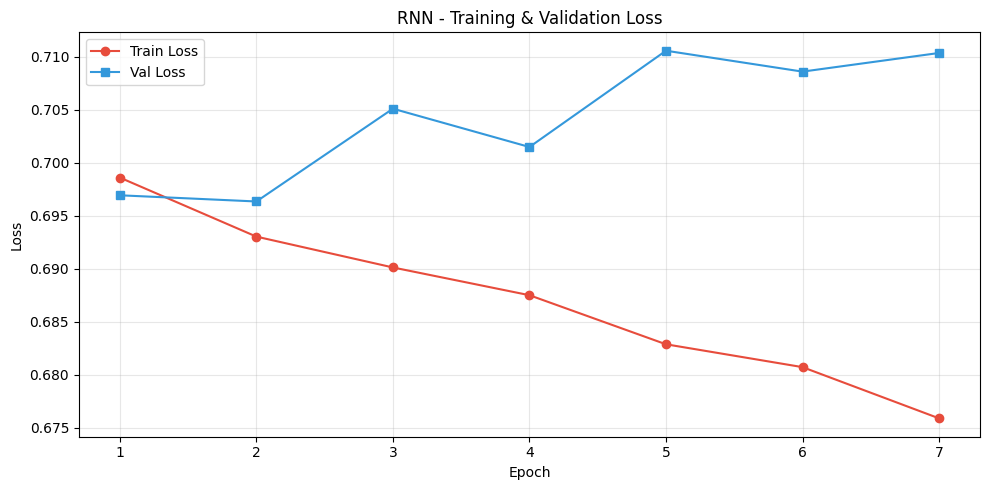

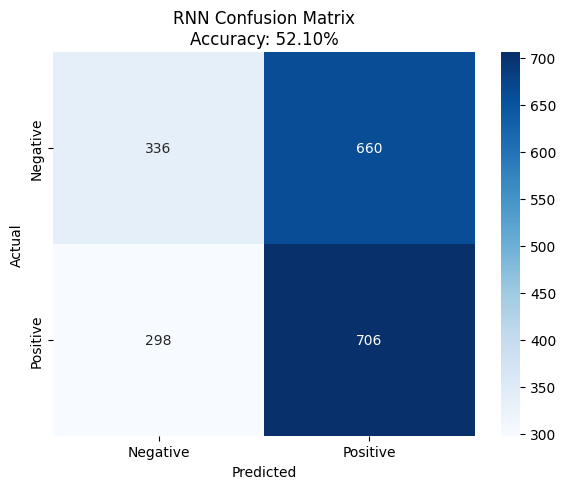

In [ ]:
# ============ RNN Train and Val Loss Curve ============
epochs_range = range(1, len(rnn_history2['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, rnn_history2['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, rnn_history2['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ RNN Confusion Matrix ============

y_true, y_pred = get_predictions(model2, test_loader)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'RNN Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

# Decreased max_seq_len (200->150)

In [ ]:
all_words = [word for review in df['review_split'] for word in review]
vocab = sorted(list(set(all_words)))
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
vocab_size = len(word_to_idx) + 1

max_seq_len = 150

def encode_safe(text_list):
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in text_list]
    encoded = encoded[:max_seq_len]
    return encoded + [0] * (max_seq_len - len(encoded))

df['encoded_review'] = df['review_split'].apply(encode_safe)

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

class SentimentDataset(Dataset):
    def __init__(self, data):
        self.texts = list(data['encoded_review'])
        self.labels = list(data['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

train_loader = DataLoader(SentimentDataset(train_data), batch_size=32, shuffle=True)
test_loader = DataLoader(SentimentDataset(test_data), batch_size=32, shuffle=False)

In [ ]:
model3 = SentimentRNN2(vocab_size, embed_size=128, hidden_size=128, output_size=2, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.0005, weight_decay=1e-4)
rnn_history3 = train_model(model3, train_loader, test_loader)

Starting Training...
Epoch 1/15 | Train Loss: 0.7017 | Val Loss: 0.6963 | Train Acc: 50.41% | Val Acc: 49.00% | 2.1s
Epoch 2/15 | Train Loss: 0.6953 | Val Loss: 0.6966 | Train Acc: 51.24% | Val Acc: 49.65% | 2.1s
Epoch 3/15 | Train Loss: 0.6890 | Val Loss: 0.6992 | Train Acc: 53.23% | Val Acc: 50.90% | 1.9s
Epoch 4/15 | Train Loss: 0.6850 | Val Loss: 0.6976 | Train Acc: 54.04% | Val Acc: 51.15% | 1.9s
Epoch 5/15 | Train Loss: 0.6782 | Val Loss: 0.6960 | Train Acc: 55.69% | Val Acc: 52.35% | 2.4s
Epoch 6/15 | Train Loss: 0.6741 | Val Loss: 0.6991 | Train Acc: 56.94% | Val Acc: 52.05% | 2.4s
Epoch 7/15 | Train Loss: 0.6673 | Val Loss: 0.6926 | Train Acc: 58.12% | Val Acc: 53.35% | 3.6s
Epoch 8/15 | Train Loss: 0.6598 | Val Loss: 0.6933 | Train Acc: 58.88% | Val Acc: 56.65% | 2.3s
Epoch 9/15 | Train Loss: 0.6733 | Val Loss: 0.7176 | Train Acc: 57.74% | Val Acc: 51.30% | 1.8s
Epoch 10/15 | Train Loss: 0.6581 | Val Loss: 0.7037 | Train Acc: 59.48% | Val Acc: 53.35% | 2.4s
Epoch 11/15 | Trai

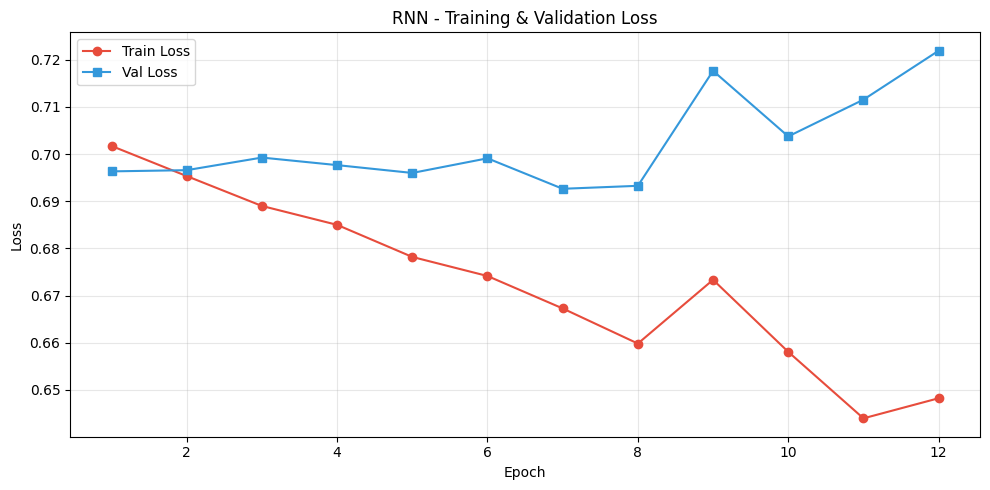

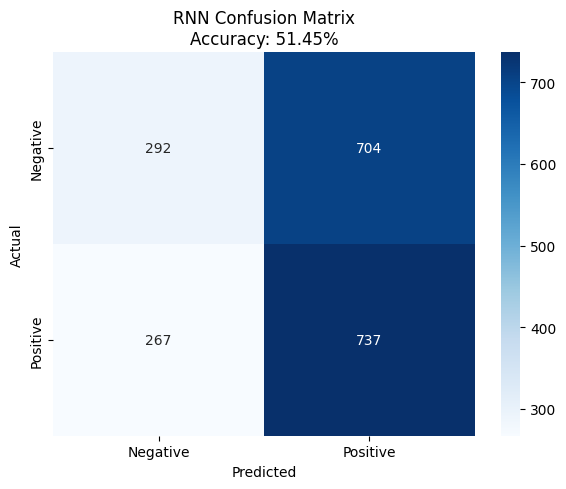

In [ ]:
# ============ RNN Train and Val Loss Curve ============
epochs_range = range(1, len(rnn_history3['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, rnn_history3['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, rnn_history3['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============ RNN Confusion Matrix ============

y_true, y_pred3 = get_predictions(model3, test_loader)
cm = confusion_matrix(y_true, y_pred3)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'RNN Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

# Decreased max_seq_len (200->100)

In [ ]:
all_words = [word for review in df['review_split'] for word in review]
vocab = sorted(list(set(all_words)))
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
vocab_size = len(word_to_idx) + 1

max_seq_len = 100

def encode_safe(text_list):
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in text_list]
    encoded = encoded[:max_seq_len]
    return encoded + [0] * (max_seq_len - len(encoded))

df['encoded_review'] = df['review_split'].apply(encode_safe)
df.head()

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

class SentimentDataset(Dataset):
    def __init__(self, data):
        self.texts = list(data['encoded_review'])
        self.labels = list(data['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

train_loader = DataLoader(SentimentDataset(train_data), batch_size=32, shuffle=True)
test_loader = DataLoader(SentimentDataset(test_data), batch_size=32, shuffle=False)

In [ ]:
model4 = SentimentRNN2(vocab_size, embed_size=128, hidden_size=128, output_size=2, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=0.0005, weight_decay=1e-4)
rnn_history4 = train_model(model4, train_loader, test_loader)

Epoch 1 | Train Loss 0.7065 | Val Loss 0.6974 | Train Acc 50.50% | Val Acc 50.20% | 1.9s
Epoch 2 | Train Loss 0.6897 | Val Loss 0.7002 | Train Acc 53.66% | Val Acc 52.00% | 2.2s
Epoch 3 | Train Loss 0.6807 | Val Loss 0.6983 | Train Acc 56.80% | Val Acc 52.20% | 2.7s
Epoch 4 | Train Loss 0.6552 | Val Loss 0.7311 | Train Acc 60.96% | Val Acc 50.80% | 2.1s
Epoch 5 | Train Loss 0.6469 | Val Loss 0.7517 | Train Acc 62.34% | Val Acc 50.55% | 1.8s
Epoch 6 | Train Loss 0.6169 | Val Loss 0.7117 | Train Acc 65.79% | Val Acc 56.45% | 1.8s
Early stopping triggered


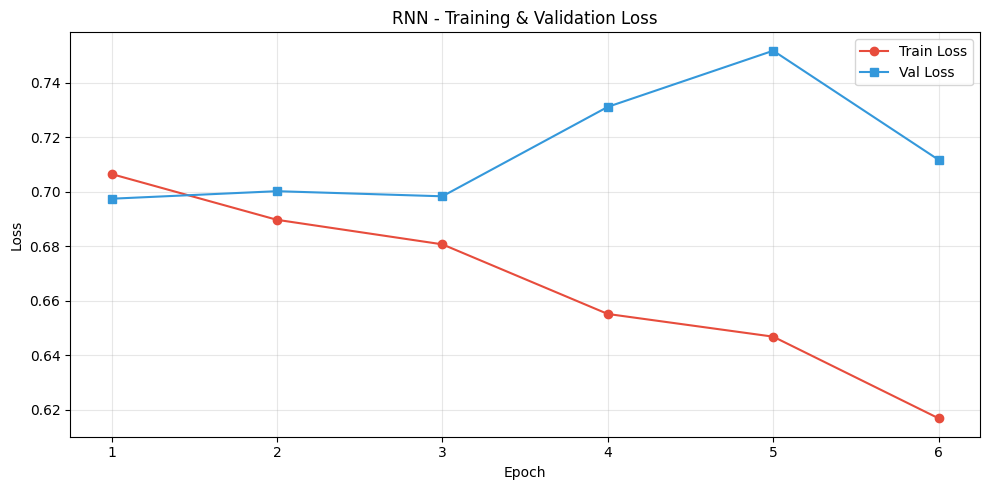

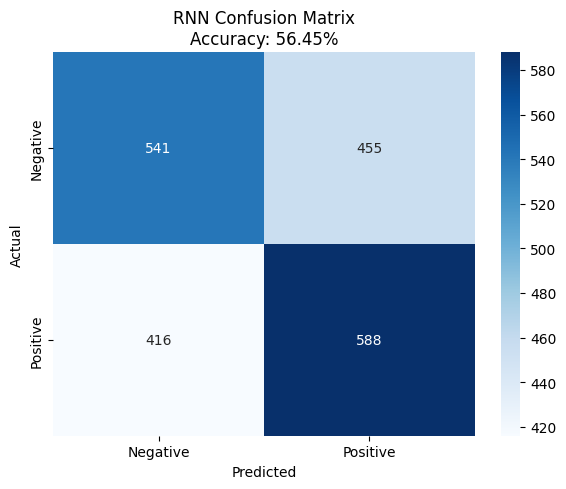

In [ ]:
# ============  RNN Train and Val Loss Curve ============
epochs_range = range(1, len(rnn_history4['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, rnn_history4['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, rnn_history4['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============  RNN Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred4 = get_predictions(model4, test_loader)
cm = confusion_matrix(y_true, y_pred4)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'RNN Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

# BiRNN

In [ ]:
class SentimentBiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.3):
        super(SentimentBiRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = 2
        self.num_directions = 2
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)

        self.rnn = nn.RNN(
            embed_size,
            hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.fc_dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        embedded = self.embedding(x)

        h0 = torch.zeros(
            self.num_layers * self.num_directions,
            x.size(0),
            self.hidden_size
        ).to(x.device)

        out, _ = self.rnn(embedded, h0)

        out = self.fc_dropout(out[:, -1, :])

        return self.fc(out)

In [ ]:
model5 = SentimentBiRNN(vocab_size, embed_size=128, hidden_size=128, output_size=2, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=0.0005)
rnn_history5 = train_model(model5, train_loader, test_loader)

Starting Training...
Epoch 1/15 | Train Loss: 0.7078 | Val Loss: 0.6992 | Train Acc: 50.36% | Val Acc: 51.80% | 3.9s
Epoch 2/15 | Train Loss: 0.6886 | Val Loss: 0.6963 | Train Acc: 55.35% | Val Acc: 52.85% | 2.1s
Epoch 3/15 | Train Loss: 0.6699 | Val Loss: 0.7048 | Train Acc: 59.11% | Val Acc: 53.10% | 2.4s
Epoch 4/15 | Train Loss: 0.6353 | Val Loss: 0.6984 | Train Acc: 64.94% | Val Acc: 59.65% | 2.6s
Epoch 5/15 | Train Loss: 0.6247 | Val Loss: 0.7644 | Train Acc: 64.81% | Val Acc: 51.90% | 3.5s
Epoch 6/15 | Train Loss: 0.5764 | Val Loss: 0.8235 | Train Acc: 69.40% | Val Acc: 54.00% | 2.7s
Epoch 7/15 | Train Loss: 0.5611 | Val Loss: 0.8319 | Train Acc: 71.22% | Val Acc: 55.20% | 2.4s

Early stopping at epoch 7! Val loss hasn't improved for 5 epochs.


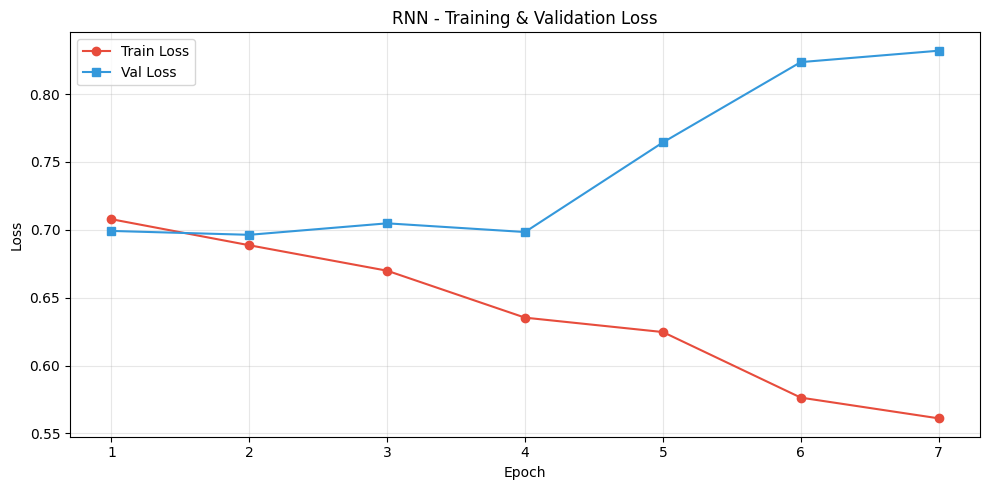

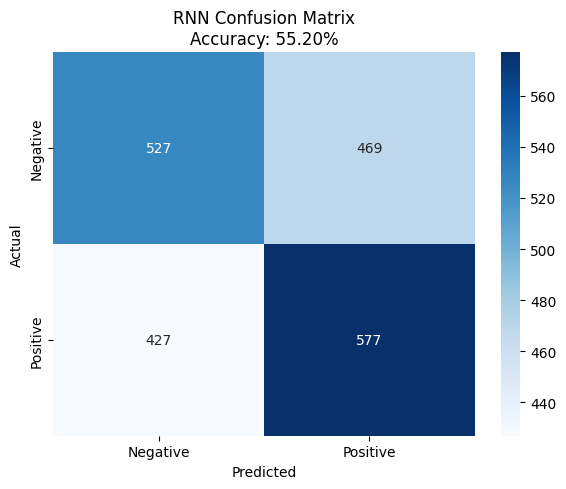

In [ ]:
# ============  RNN Train and Val Loss Curve ============
epochs_range = range(1, len(rnn_history5['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, rnn_history5['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, rnn_history5['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


y_true, y_pred5 = get_predictions(model5, test_loader)
cm = confusion_matrix(y_true, y_pred5)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'RNN Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [134]:
updated_rnn=model4
rnn_pred=y_pred4
improved_rnn_history=rnn_history4

# LSTM

In [ ]:
all_words = [word for review in df['review_split'] for word in review]
vocab = sorted(list(set(all_words)))
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
vocab_size = len(word_to_idx) + 1

max_seq_len = 200

def encode_safe(text_list):
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in text_list]
    encoded = encoded[:max_seq_len]
    return encoded + [0] * (max_seq_len - len(encoded))

df['encoded_review'] = df['review_split'].apply(encode_safe)

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

class SentimentDataset(Dataset):
    def __init__(self, data):
        # We use the actual column names from our dataframe
        self.texts = list(data['encoded_review'])
        self.labels = list(data['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

train_loader = DataLoader(SentimentDataset(train_data), batch_size=32, shuffle=True)
test_loader = DataLoader(SentimentDataset(test_data), batch_size=32, shuffle=False)

## Added embedding dropout layer(with dropout=0.3), increased dropout of lstm layer(0.3->0.4), increased dropout after lstm layer (0.3->0.5)
## Weight decay = 1e-5

In [ ]:
class SentimentLSTM2(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentLSTM2, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embed_dropout = nn.Dropout(0.3)

        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.4)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, verbose=False):
        if verbose: print(f"Input Shape: {x.shape}")

        embedded = self.embed_dropout(self.embedding(x))

        out, (hn, cn) = self.lstm(embedded)

        last_step = out[:, -1, :]

        last_step = self.dropout(last_step)

        return self.fc(last_step)

model2 = SentimentLSTM2(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

In [ ]:
lstm_history2 = train_model(model2, train_loader, test_loader, epochs=15)

Epoch 1 | Train Loss 0.6944 | Val Loss 0.6928 | Train Acc 50.81% | Val Acc 50.05% | 2.9s
Epoch 2 | Train Loss 0.6895 | Val Loss 0.6899 | Train Acc 52.55% | Val Acc 51.25% | 2.8s
Epoch 3 | Train Loss 0.6711 | Val Loss 0.6901 | Train Acc 57.29% | Val Acc 51.95% | 2.8s
Epoch 4 | Train Loss 0.6411 | Val Loss 0.8017 | Train Acc 58.90% | Val Acc 52.45% | 3.0s
Epoch 5 | Train Loss 0.6017 | Val Loss 0.7206 | Train Acc 62.69% | Val Acc 54.90% | 3.0s
Epoch 6 | Train Loss 0.5576 | Val Loss 0.8819 | Train Acc 66.49% | Val Acc 63.40% | 3.4s
Epoch 7 | Train Loss 0.4927 | Val Loss 0.6936 | Train Acc 74.76% | Val Acc 70.75% | 3.5s
Early stopping triggered


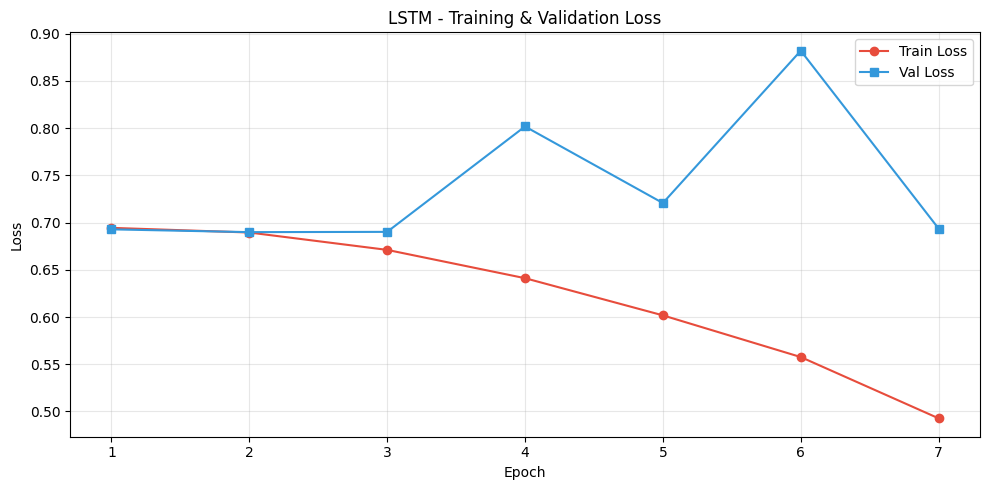

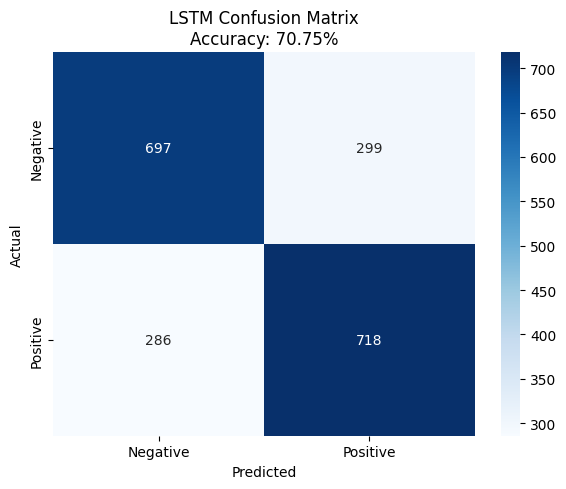

In [ ]:
# ============ LSTM Train and Val Loss Curve ============
epochs_range = range(1, len(lstm_history2['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, lstm_history2['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, lstm_history2['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============  LSTM Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred2 = get_predictions(model2, test_loader)
cm = confusion_matrix(y_true, y_pred2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'LSTM Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

## Decreased hidden_size(128->64)

In [ ]:
# 2. Re-Initialize with LSTM
model3 = SentimentLSTM2(vocab_size, 128, 64, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.001)


lstm_history3 = train_model(model3, train_loader, test_loader, epochs=15)

Epoch 1 | Train Loss 0.6942 | Val Loss 0.6933 | Train Acc 50.38% | Val Acc 49.95% | 2.0s
Epoch 2 | Train Loss 0.6923 | Val Loss 0.6965 | Train Acc 51.71% | Val Acc 50.10% | 2.0s
Epoch 3 | Train Loss 0.6848 | Val Loss 0.7034 | Train Acc 53.88% | Val Acc 51.65% | 2.0s
Epoch 4 | Train Loss 0.6642 | Val Loss 0.6924 | Train Acc 56.90% | Val Acc 52.80% | 2.0s
Epoch 5 | Train Loss 0.6240 | Val Loss 0.7434 | Train Acc 61.21% | Val Acc 55.80% | 2.0s
Epoch 6 | Train Loss 0.5849 | Val Loss 0.7332 | Train Acc 62.04% | Val Acc 54.30% | 3.6s
Epoch 7 | Train Loss 0.5515 | Val Loss 0.7575 | Train Acc 65.53% | Val Acc 57.80% | 2.5s
Epoch 8 | Train Loss 0.5176 | Val Loss 0.8283 | Train Acc 69.34% | Val Acc 66.00% | 3.5s
Epoch 9 | Train Loss 0.4504 | Val Loss 0.8035 | Train Acc 77.42% | Val Acc 71.55% | 3.1s
Early stopping triggered


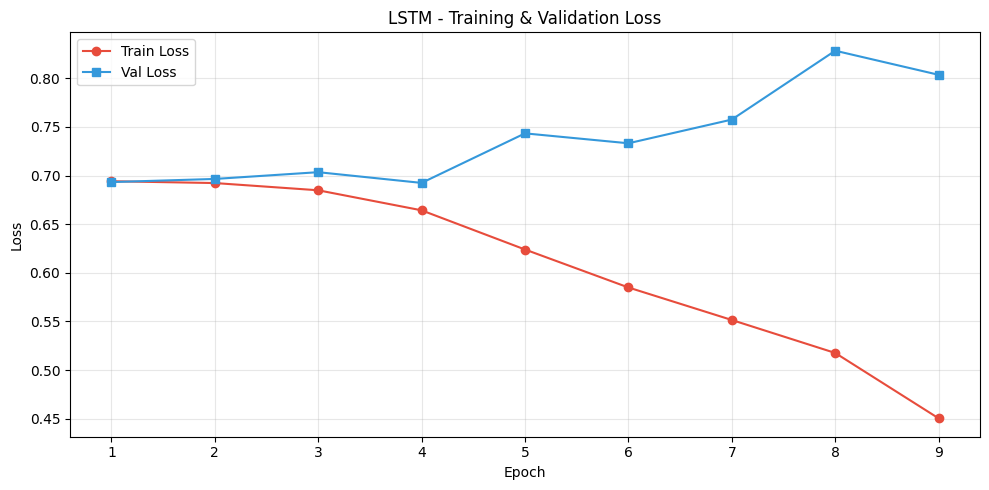

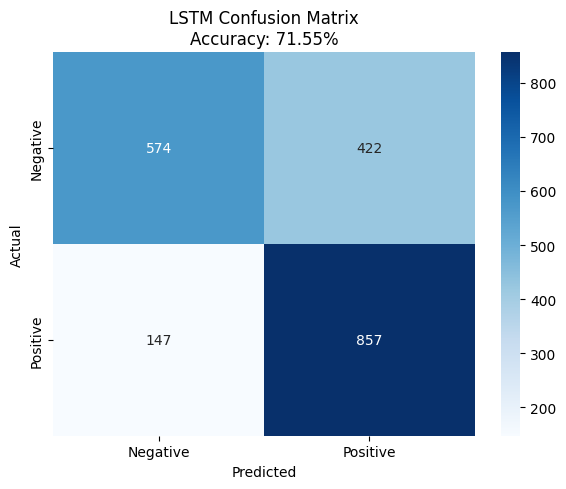

In [ ]:
# ============ LSTM Train and Val Loss Curve ============
epochs_range = range(1, len(lstm_history3['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, lstm_history3['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, lstm_history3['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



y_true, y_pred3 = get_predictions(model3, test_loader)
cm = confusion_matrix(y_true, y_pred3)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'LSTM Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

# Updated train model (Gradient Clipping, Learning Rate Scheduling)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, patience=5):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=3,
        factor=0.5
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):

        start = time.time()

        model.train()

        train_loss = 0
        correct = 0
        total = 0

        for texts, labels in train_loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

            optimizer.step()

            train_loss += loss.item()

            _, pred = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (pred == labels).sum().item()

        train_acc = 100 * correct / total

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for texts, labels in val_loader:

                texts = texts.to(device)
                labels = labels.to(device)

                outputs = model(texts)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, pred = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (pred == labels).sum().item()

        val_acc = 100 * correct / total

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(avg_val_loss)

        duration = time.time() - start

        print(f"Epoch {epoch+1} | Train Loss {avg_train_loss:.4f} | "
              f"Val Loss {avg_val_loss:.4f} | "
              f"Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}% | {duration:.1f}s")

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss
            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print("Early stopping triggered")

                break

    return history

In [ ]:
model4 = SentimentLSTM2(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=0.001,weight_decay=1e-5)

lstm_history4 = train_model(model4, train_loader, test_loader, epochs=15)

Epoch 1 | Train Loss 0.6939 | Val Loss 0.6945 | Train Acc 51.65% | Val Acc 52.55% | 3.7s
Epoch 2 | Train Loss 0.6844 | Val Loss 0.6910 | Train Acc 54.55% | Val Acc 52.65% | 5.6s
Epoch 3 | Train Loss 0.6610 | Val Loss 0.6963 | Train Acc 56.95% | Val Acc 52.80% | 3.5s
Epoch 4 | Train Loss 0.6259 | Val Loss 0.6878 | Train Acc 60.71% | Val Acc 54.70% | 3.4s
Epoch 5 | Train Loss 0.5947 | Val Loss 0.7321 | Train Acc 62.02% | Val Acc 53.65% | 3.8s
Epoch 6 | Train Loss 0.5534 | Val Loss 0.7860 | Train Acc 64.58% | Val Acc 54.00% | 3.7s
Epoch 7 | Train Loss 0.5111 | Val Loss 0.8016 | Train Acc 67.09% | Val Acc 56.00% | 2.9s
Epoch 8 | Train Loss 0.4836 | Val Loss 0.8878 | Train Acc 68.70% | Val Acc 55.60% | 2.9s
Epoch 9 | Train Loss 0.4543 | Val Loss 0.8526 | Train Acc 72.36% | Val Acc 69.50% | 3.0s
Early stopping triggered


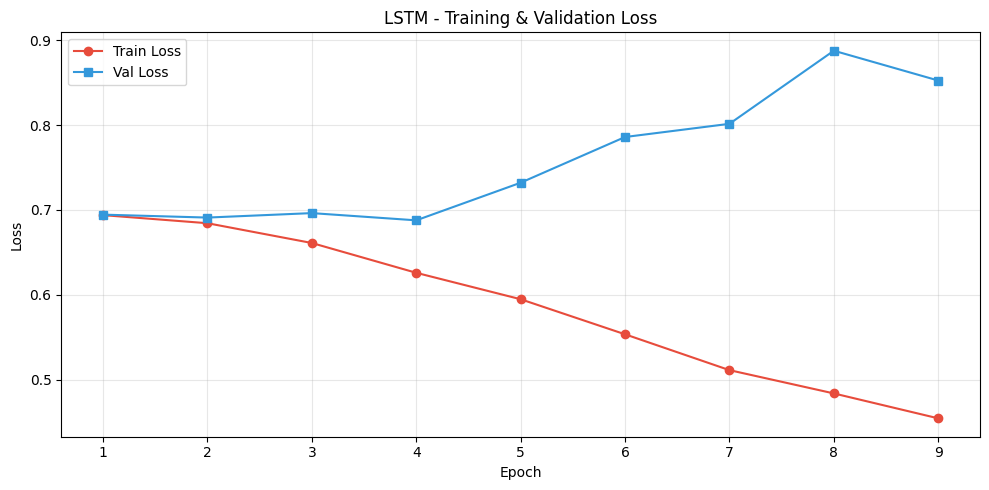

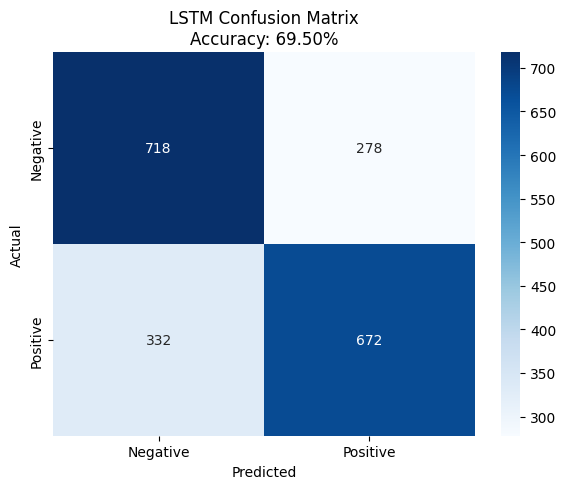

In [ ]:
# ============ LSTM Train and Val Loss Curve ============
epochs_range = range(1, len(lstm_history4['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, lstm_history4['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, lstm_history4['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



y_true, y_pred4 = get_predictions(model4, test_loader)
cm = confusion_matrix(y_true, y_pred4)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'LSTM Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [ ]:
model5 = SentimentLSTM2(vocab_size, 128, 64, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=0.001,weight_decay=1e-5)

lstm_history5 = train_model(model5, train_loader, test_loader, epochs=15)

Epoch 1 | Train Loss 0.6946 | Val Loss 0.6933 | Train Acc 50.38% | Val Acc 49.85% | 2.0s
Epoch 2 | Train Loss 0.6924 | Val Loss 0.6917 | Train Acc 51.54% | Val Acc 50.65% | 2.0s
Epoch 3 | Train Loss 0.6838 | Val Loss 0.6825 | Train Acc 53.60% | Val Acc 53.45% | 2.0s
Epoch 4 | Train Loss 0.6567 | Val Loss 0.6936 | Train Acc 57.96% | Val Acc 53.75% | 2.0s
Epoch 5 | Train Loss 0.6162 | Val Loss 0.7123 | Train Acc 61.59% | Val Acc 54.70% | 2.0s
Epoch 6 | Train Loss 0.5730 | Val Loss 0.7054 | Train Acc 64.21% | Val Acc 55.95% | 2.4s
Epoch 7 | Train Loss 0.5409 | Val Loss 0.7402 | Train Acc 65.28% | Val Acc 57.55% | 2.0s
Epoch 8 | Train Loss 0.4781 | Val Loss 0.7007 | Train Acc 76.45% | Val Acc 69.60% | 2.0s
Early stopping triggered


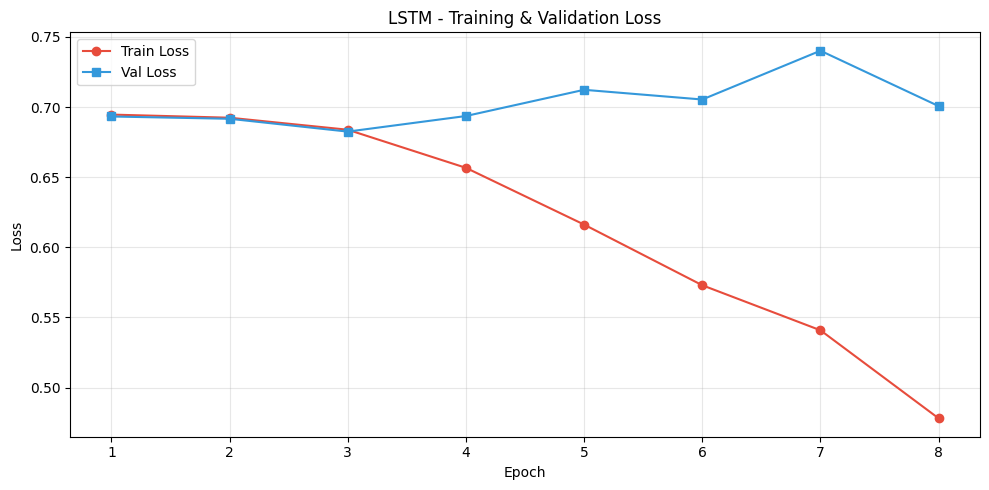

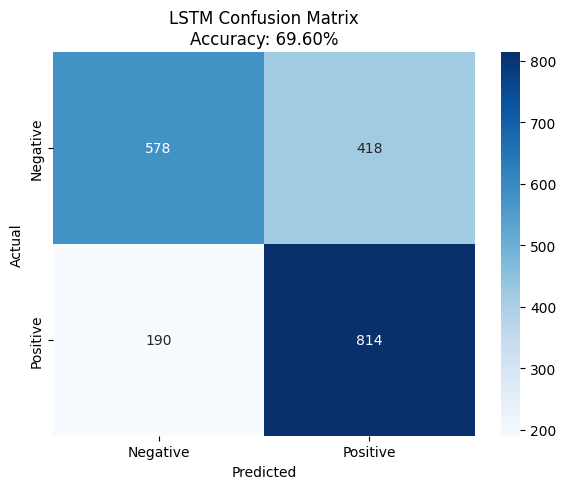

In [ ]:
# ============ LSTM Train and Val Loss Curve ============
epochs_range = range(1, len(lstm_history5['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, lstm_history5['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, lstm_history5['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



y_true, y_pred5 = get_predictions(model5, test_loader)
cm = confusion_matrix(y_true, y_pred5)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'LSTM Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [133]:
updated_lstm=model5
lstm_pred=y_pred5
improved_lstm_history=lstm_history5

# GRU

In [ ]:
# Original train_model

def train_model(model, train_loader, val_loader, epochs=15, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Starting Training...")
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Store metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(100 * train_correct / train_total)
        history['val_acc'].append(100 * val_correct / val_total)

        duration = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}% | {duration:.1f}s")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}! Val loss hasn't improved for {patience} epochs.")
                break

    return history

## Added embedding dropout layer(with dropout=0.3), increased dropout of lstm layer(0.3->0.4), increased dropout after lstm layer (0.3->0.5)
## Weight decay = 1e-5

In [ ]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embed_dropout = nn.Dropout(0.3)
        # GRU is similar to LSTM but faster and often just as effective
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.4)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, verbose=False):
        if verbose: print(f"Input Shape: {x.shape}")

        embedded = self.embed_dropout(self.embedding(x))

        out, hn = self.gru(embedded)

        last_step = out[:, -1, :]

        last_step = self.dropout(last_step)

        return self.fc(last_step)

model2 = SentimentGRU(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001,weight_decay=1e-5)

# GRU usually converges faster than LSTM
gru_history2 = train_model(model2, train_loader, test_loader, epochs=15)

Starting Training...
Epoch 1/15 | Train Loss: 0.7043 | Val Loss: 0.7177 | Train Acc: 50.94% | Val Acc: 49.35% | 2.6s
Epoch 2/15 | Train Loss: 0.6966 | Val Loss: 0.6989 | Train Acc: 52.24% | Val Acc: 50.15% | 2.4s
Epoch 3/15 | Train Loss: 0.6935 | Val Loss: 0.6901 | Train Acc: 52.95% | Val Acc: 51.45% | 2.3s
Epoch 4/15 | Train Loss: 0.6661 | Val Loss: 0.7001 | Train Acc: 59.96% | Val Acc: 50.55% | 2.3s
Epoch 5/15 | Train Loss: 0.6759 | Val Loss: 0.6455 | Train Acc: 56.39% | Val Acc: 64.15% | 2.3s
Epoch 6/15 | Train Loss: 0.5385 | Val Loss: 0.5439 | Train Acc: 73.47% | Val Acc: 76.30% | 2.5s
Epoch 7/15 | Train Loss: 0.3614 | Val Loss: 0.4363 | Train Acc: 85.10% | Val Acc: 81.70% | 2.8s
Epoch 8/15 | Train Loss: 0.2349 | Val Loss: 0.4240 | Train Acc: 90.72% | Val Acc: 83.35% | 3.0s
Epoch 9/15 | Train Loss: 0.1387 | Val Loss: 0.5249 | Train Acc: 95.10% | Val Acc: 83.05% | 2.7s
Epoch 10/15 | Train Loss: 0.0919 | Val Loss: 0.5501 | Train Acc: 96.88% | Val Acc: 83.30% | 2.8s
Epoch 11/15 | Trai

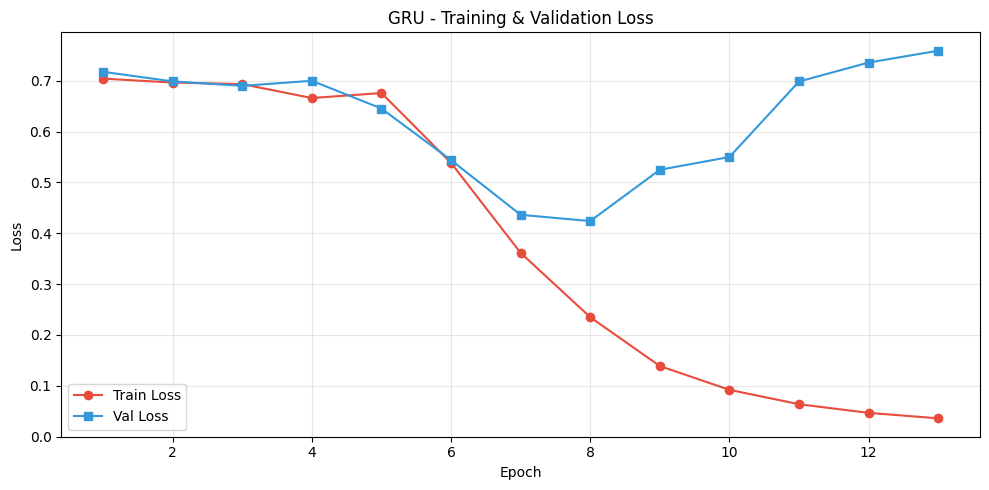

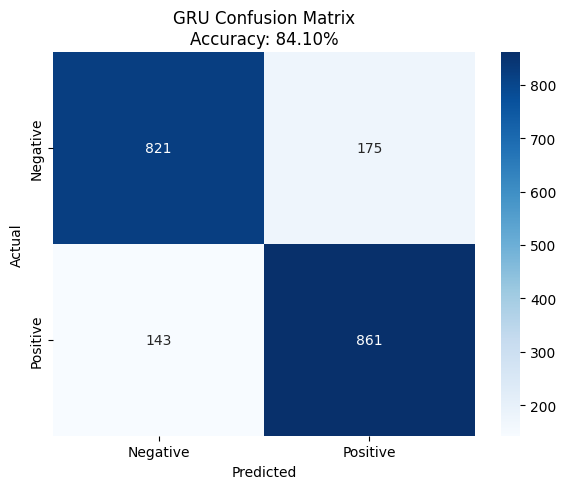

In [ ]:
# ============ GRU Train and Val Loss Curve ============
epochs_range = range(1, len(gru_history2['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, gru_history2['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, gru_history2['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============  GRU Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred2 = get_predictions(model2, test_loader)
cm = confusion_matrix(y_true, y_pred2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'GRU Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

## Decreased hidden_size(128->64)

In [ ]:
model3 = SentimentGRU(vocab_size, 128, 64, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.001,weight_decay=1e-5)

# GRU usually converges faster than LSTM
gru_history3 = train_model(model3, train_loader, test_loader, epochs=15)

Starting Training...
Epoch 1/15 | Train Loss: 0.7000 | Val Loss: 0.6945 | Train Acc: 51.23% | Val Acc: 49.30% | 2.1s
Epoch 2/15 | Train Loss: 0.6960 | Val Loss: 0.6916 | Train Acc: 51.50% | Val Acc: 50.20% | 1.9s
Epoch 3/15 | Train Loss: 0.6778 | Val Loss: 0.6455 | Train Acc: 56.86% | Val Acc: 63.35% | 2.1s
Epoch 4/15 | Train Loss: 0.6067 | Val Loss: 0.5788 | Train Acc: 67.33% | Val Acc: 70.35% | 2.5s
Epoch 5/15 | Train Loss: 0.4879 | Val Loss: 0.4967 | Train Acc: 78.24% | Val Acc: 78.25% | 4.7s
Epoch 6/15 | Train Loss: 0.3704 | Val Loss: 0.4623 | Train Acc: 84.53% | Val Acc: 81.55% | 3.1s
Epoch 7/15 | Train Loss: 0.2740 | Val Loss: 0.4499 | Train Acc: 89.65% | Val Acc: 83.90% | 2.7s
Epoch 8/15 | Train Loss: 0.1975 | Val Loss: 0.4369 | Train Acc: 92.80% | Val Acc: 83.20% | 2.9s
Epoch 9/15 | Train Loss: 0.1434 | Val Loss: 0.4902 | Train Acc: 94.86% | Val Acc: 83.05% | 3.8s
Epoch 10/15 | Train Loss: 0.1063 | Val Loss: 0.5982 | Train Acc: 96.22% | Val Acc: 84.30% | 3.1s
Epoch 11/15 | Trai

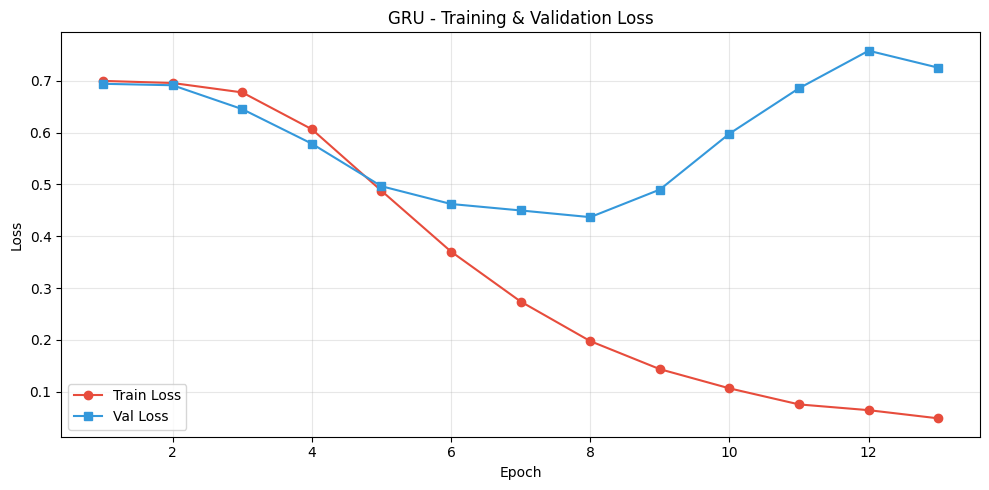

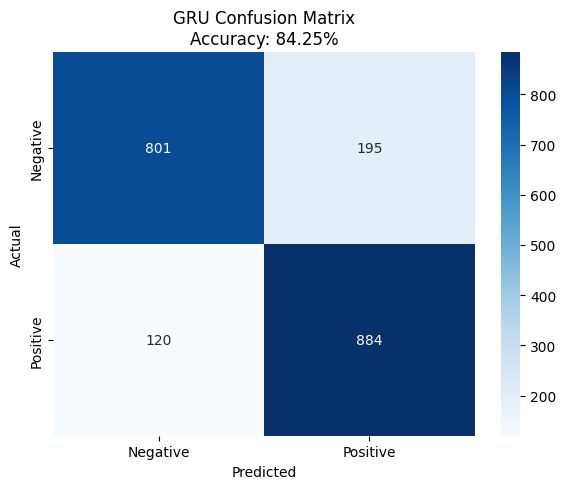

In [ ]:
# ============ GRU Train and Val Loss Curve ============
epochs_range = range(1, len(gru_history3['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, gru_history3['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, gru_history3['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============  GRU Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred3 = get_predictions(model3, test_loader)
cm = confusion_matrix(y_true, y_pred3)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'GRU Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

# Updated train model (Gradient Clipping, Learning Rate Scheduling)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, patience=5):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=3,
        factor=0.5
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):

        start = time.time()

        model.train()

        train_loss = 0
        correct = 0
        total = 0

        for texts, labels in train_loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

            optimizer.step()

            train_loss += loss.item()

            _, pred = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (pred == labels).sum().item()

        train_acc = 100 * correct / total

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for texts, labels in val_loader:

                texts = texts.to(device)
                labels = labels.to(device)

                outputs = model(texts)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, pred = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (pred == labels).sum().item()

        val_acc = 100 * correct / total

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(avg_val_loss)

        duration = time.time() - start

        print(f"Epoch {epoch+1} | Train Loss {avg_train_loss:.4f} | "
              f"Val Loss {avg_val_loss:.4f} | "
              f"Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}% | {duration:.1f}s")

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss
            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print("Early stopping triggered")

                break

    return history

In [116]:
model4 = SentimentGRU(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=0.001,weight_decay=1e-5)

# GRU usually converges faster than LSTM
gru_history4 = train_model(model4, train_loader, test_loader, epochs=15)

Epoch 1 | Train Loss 0.7037 | Val Loss 0.6937 | Train Acc 50.66% | Val Acc 49.75% | 2.3s
Epoch 2 | Train Loss 0.6957 | Val Loss 0.6942 | Train Acc 52.48% | Val Acc 49.85% | 2.3s
Epoch 3 | Train Loss 0.6895 | Val Loss 0.6864 | Train Acc 54.42% | Val Acc 53.65% | 2.5s
Epoch 4 | Train Loss 0.6496 | Val Loss 0.6114 | Train Acc 61.92% | Val Acc 67.65% | 2.4s
Epoch 5 | Train Loss 0.5353 | Val Loss 0.4857 | Train Acc 72.85% | Val Acc 79.30% | 2.3s
Epoch 6 | Train Loss 0.3666 | Val Loss 0.4584 | Train Acc 84.47% | Val Acc 82.15% | 2.3s
Epoch 7 | Train Loss 0.2557 | Val Loss 0.4475 | Train Acc 89.89% | Val Acc 82.95% | 2.3s
Epoch 8 | Train Loss 0.1839 | Val Loss 0.4534 | Train Acc 92.89% | Val Acc 83.35% | 2.4s
Epoch 9 | Train Loss 0.1420 | Val Loss 0.5059 | Train Acc 94.44% | Val Acc 83.65% | 2.4s
Epoch 10 | Train Loss 0.1142 | Val Loss 0.5359 | Train Acc 95.66% | Val Acc 84.35% | 2.3s
Epoch 11 | Train Loss 0.0782 | Val Loss 0.6904 | Train Acc 97.24% | Val Acc 83.45% | 2.3s
Epoch 12 | Train Lo

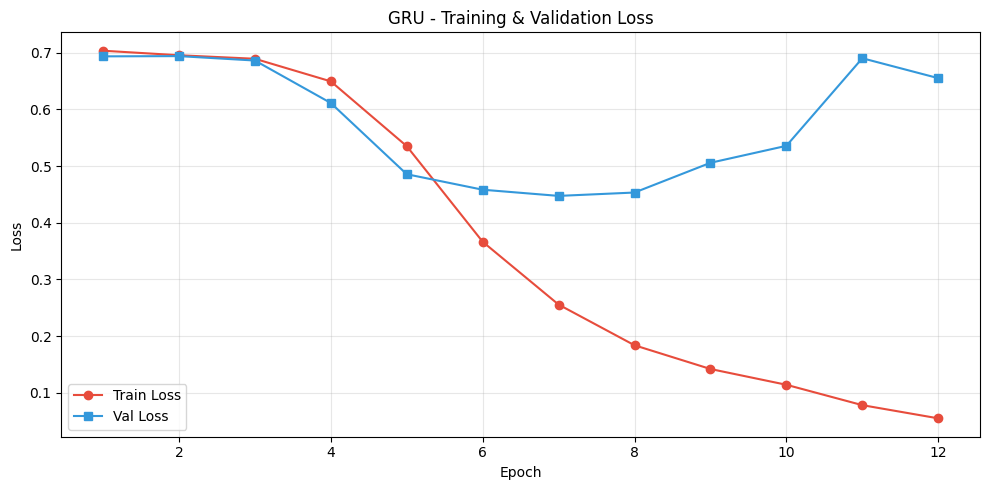

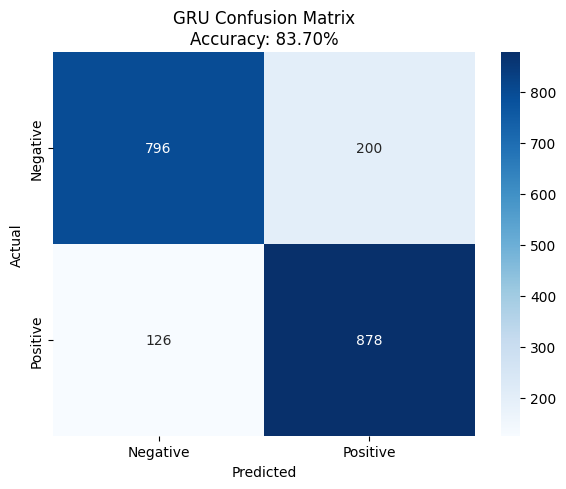

In [117]:
# ============ GRU Train and Val Loss Curve ============
epochs_range = range(1, len(gru_history4['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, gru_history4['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, gru_history4['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============  GRU Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred4 = get_predictions(model4, test_loader)
cm = confusion_matrix(y_true, y_pred4)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'GRU Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

## Decreased hidden_size(128->64)

In [ ]:
model5 = SentimentGRU(vocab_size, 128, 64, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=0.001,weight_decay=1e-5)

# GRU usually converges faster than LSTM
gru_history5 = train_model(model5, train_loader, test_loader, epochs=15)

Epoch 1 | Train Loss 0.7022 | Val Loss 0.6932 | Train Acc 49.83% | Val Acc 50.15% | 3.8s
Epoch 2 | Train Loss 0.6956 | Val Loss 0.6930 | Train Acc 50.96% | Val Acc 51.80% | 3.6s
Epoch 3 | Train Loss 0.6915 | Val Loss 0.6853 | Train Acc 52.91% | Val Acc 54.60% | 3.0s
Epoch 4 | Train Loss 0.6566 | Val Loss 0.6014 | Train Acc 61.05% | Val Acc 69.40% | 4.5s
Epoch 5 | Train Loss 0.6529 | Val Loss 0.6094 | Train Acc 60.35% | Val Acc 66.30% | 3.2s
Epoch 6 | Train Loss 0.5357 | Val Loss 0.6547 | Train Acc 74.64% | Val Acc 67.10% | 2.8s
Epoch 7 | Train Loss 0.4519 | Val Loss 0.5740 | Train Acc 80.38% | Val Acc 75.80% | 3.5s
Epoch 8 | Train Loss 0.3477 | Val Loss 0.5524 | Train Acc 85.85% | Val Acc 79.65% | 3.3s
Epoch 9 | Train Loss 0.2661 | Val Loss 0.5795 | Train Acc 89.91% | Val Acc 80.55% | 3.2s
Epoch 10 | Train Loss 0.2109 | Val Loss 0.5512 | Train Acc 92.25% | Val Acc 81.75% | 2.8s
Epoch 11 | Train Loss 0.1637 | Val Loss 0.5668 | Train Acc 94.09% | Val Acc 81.80% | 2.2s
Epoch 12 | Train Lo

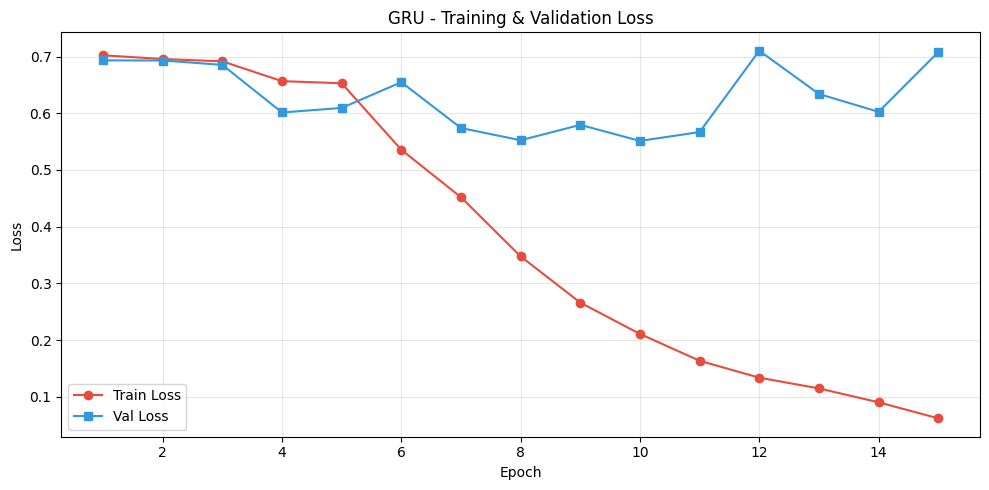

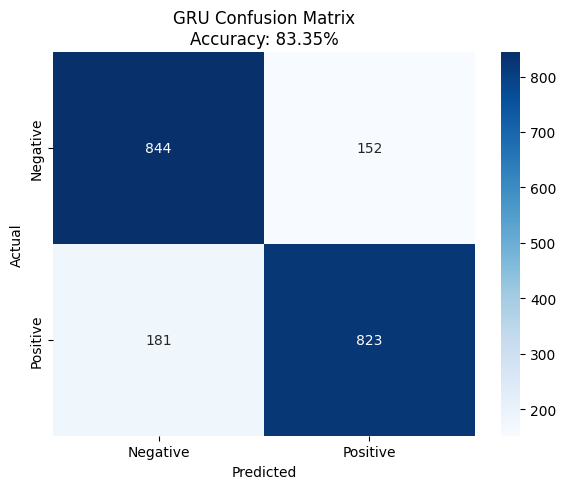

In [ ]:
# ============ GRU Train and Val Loss Curve ============
epochs_range = range(1, len(gru_history5['train_loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, gru_history5['train_loss'], label='Train Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, gru_history5['val_loss'], label='Val Loss', color='#3498db', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============  GRU Confusion Matrix ============
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred5 = get_predictions(model5, test_loader)
cm = confusion_matrix(y_true, y_pred5)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
accuracy = 100 * np.trace(cm) / np.sum(cm)
plt.title(f'GRU Confusion Matrix\nAccuracy: {accuracy:.2f}%')
plt.tight_layout()
plt.show()

In [131]:
updated_gru=model4
gru_pred=y_pred4
improved_gru_history=gru_history4

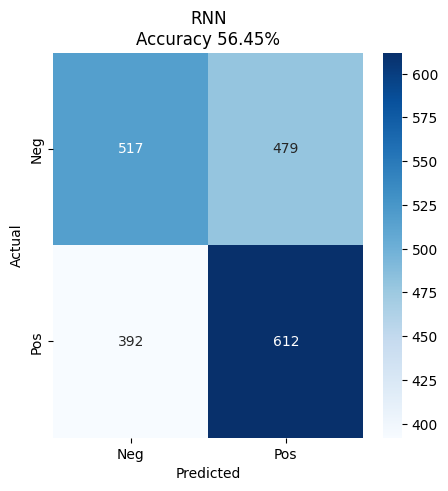

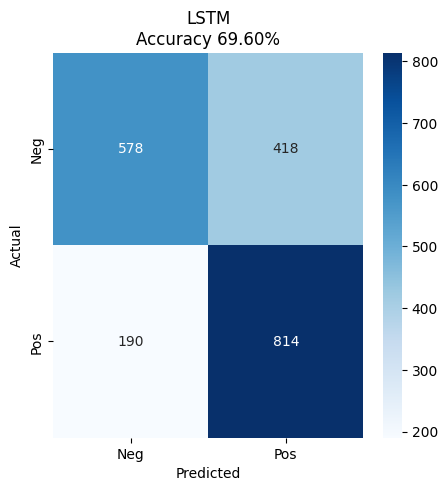

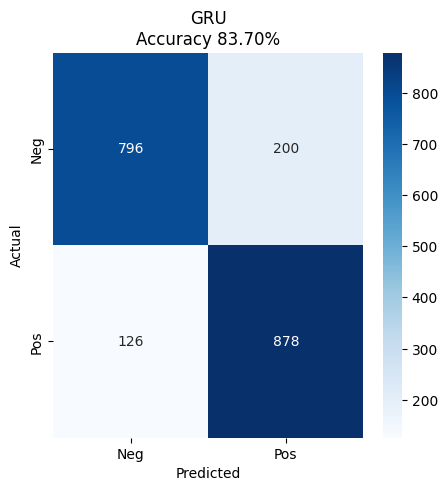

In [121]:
from sklearn.metrics import confusion_matrix, accuracy_score

def get_predictions(model, loader):

    model.eval()

    preds = []
    probs = []
    labels_all = []

    with torch.no_grad():

        for texts, labels in loader:

            texts = texts.to(device)

            outputs = model(texts)

            prob = torch.softmax(outputs, dim=1)

            _, pred = torch.max(outputs,1)

            preds.extend(pred.cpu().numpy())
            probs.extend(prob.cpu().numpy())
            labels_all.extend(labels.numpy())

    return np.array(labels_all), np.array(preds), np.array(probs)

def plot_confusion(y_true, y_pred, title):

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(5,5))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=['Neg','Pos'],
                yticklabels=['Neg','Pos'])

    acc = accuracy_score(y_true,y_pred)*100

    plt.title(f"{title}\nAccuracy {acc:.2f}%")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


y_true, rnn_pred, rnn_prob = get_predictions(updated_rnn,test_loader)
_, lstm_pred,lstm_prob  = get_predictions(updated_lstm,test_loader)
_, gru_pred,gru_prob  = get_predictions(updated_gru,test_loader)

plot_confusion(y_true,rnn_pred,"RNN")
plot_confusion(y_true,lstm_pred,"LSTM")
plot_confusion(y_true,gru_pred,"GRU")

# Phase 2

## Original vs Improved Validation Loss Plot

In [135]:
orig_rnn_val = rnn_history['val_loss']
orig_lstm_val = lstm_history['val_loss']
orig_gru_val = gru_history['val_loss']

imp_rnn_val = improved_rnn_history['val_loss']
imp_lstm_val = improved_lstm_history['val_loss']
imp_gru_val = improved_gru_history['val_loss']

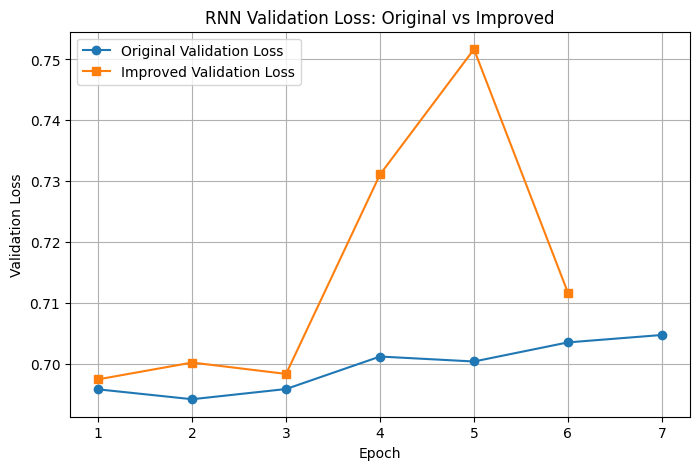

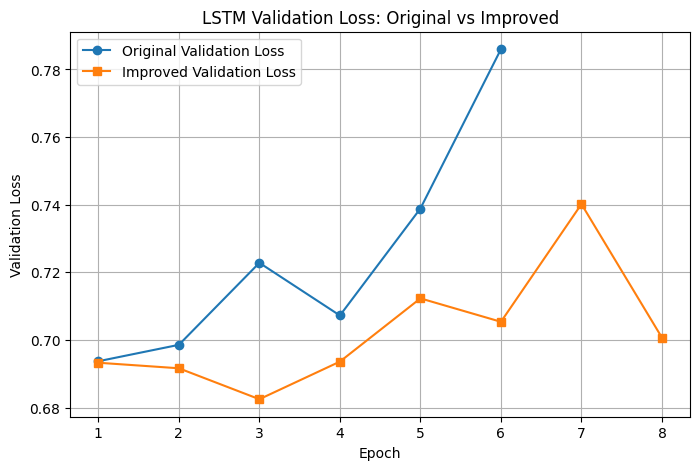

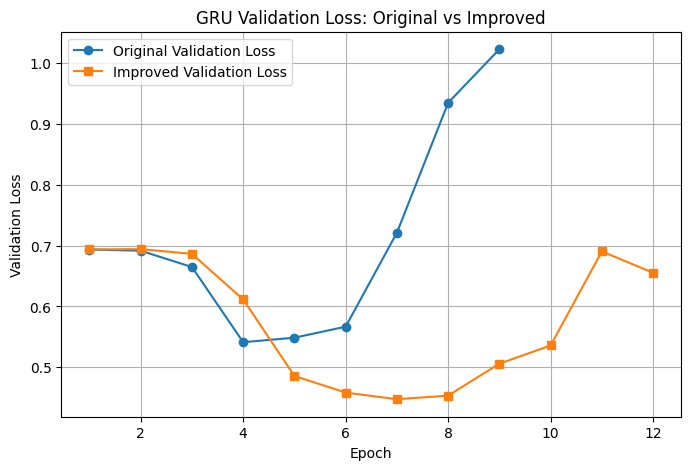

In [137]:
def plot_comparison(original, improved, title):

    epochs_orig = range(1, len(original)+1)
    epochs_imp = range(1, len(improved)+1)

    plt.figure(figsize=(8,5))

    plt.plot(epochs_orig, original, label="Original Validation Loss", marker='o')

    plt.plot(epochs_imp, improved, label="Improved Validation Loss", marker='s')

    plt.title(title)

    plt.xlabel("Epoch")

    plt.ylabel("Validation Loss")

    plt.legend()

    plt.grid(True)

    plt.show()


plot_comparison(orig_rnn_val, imp_rnn_val, "RNN Validation Loss: Original vs Improved")

plot_comparison(orig_lstm_val, imp_lstm_val, "LSTM Validation Loss: Original vs Improved")

plot_comparison(orig_gru_val, imp_gru_val, "GRU Validation Loss: Original vs Improved")

## Hard Voting

In [122]:
hard_preds = []

for i in range(len(y_true)):

    votes = [rnn_pred[i],lstm_pred[i],gru_pred[i]]

    hard_preds.append(max(set(votes),key=votes.count))

hard_preds = np.array(hard_preds)

## Soft Voting

In [123]:
soft_probs = (rnn_prob + lstm_prob + gru_prob) / 3

soft_preds = np.argmax(soft_probs,axis=1)

## Weighted Voting

In [124]:
acc_rnn = accuracy_score(y_true,rnn_pred)
acc_lstm = accuracy_score(y_true,lstm_pred)
acc_gru = accuracy_score(y_true,gru_pred)

total = acc_rnn + acc_lstm + acc_gru

w_rnn = acc_rnn / total
w_lstm = acc_lstm / total
w_gru = acc_gru / total

weighted_probs = w_rnn*rnn_prob + w_lstm*lstm_prob + w_gru*gru_prob

weighted_preds = np.argmax(weighted_probs,axis=1)

## Accuracy Table

In [125]:
results = {

"RNN": accuracy_score(y_true,rnn_pred),
"LSTM": accuracy_score(y_true,lstm_pred),
"GRU": accuracy_score(y_true,gru_pred),
"Hard Voting": accuracy_score(y_true,hard_preds),
"Soft Voting": accuracy_score(y_true,soft_preds),
"Weighted Voting": accuracy_score(y_true,weighted_preds)

}

for k,v in results.items():

    print(f"{k}: {v*100:.2f}%")

RNN: 56.45%
LSTM: 69.60%
GRU: 83.70%
Hard Voting: 76.85%
Soft Voting: 82.60%
Weighted Voting: 83.45%


## Ensemble Confusion Matrix

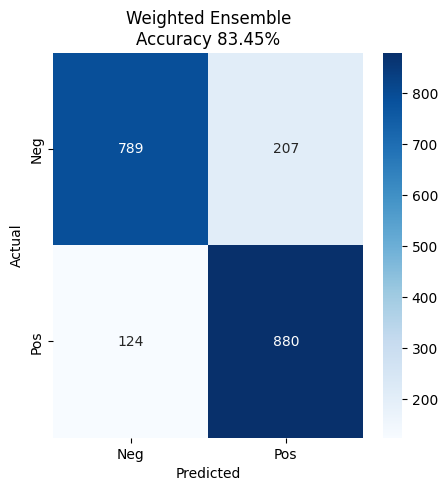

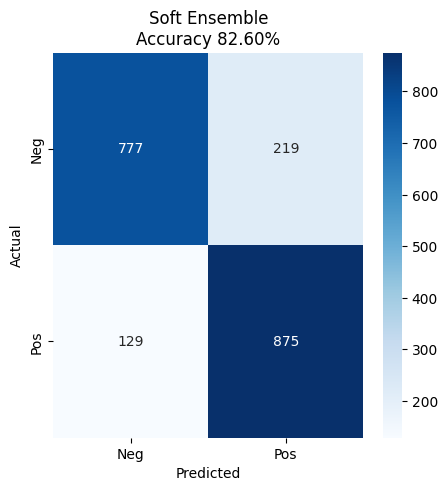

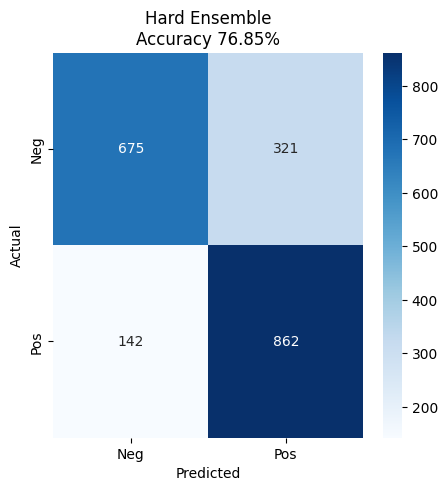

In [126]:
plot_confusion(y_true,weighted_preds,"Weighted Ensemble")
plot_confusion(y_true,soft_preds,"Soft Ensemble")
plot_confusion(y_true,hard_preds,"Hard Ensemble")

## Disagreement Examples

In [128]:
count = 0

for i in range(len(y_true)):

    # preds = [rnn_pred[i],lstm_pred[i],gru_pred[i]]

    if lstm_pred[i]!=y_true[i] and rnn_pred[i]!=y_true[i] and gru_pred[i]!=y_true[i]:

        if weighted_preds[i] == y_true[i]:

            print(f"Example {count+1}")

            print("True:",y_true[i])
            print("RNN:",rnn_pred[i])
            print("LSTM:",lstm_pred[i])
            print("GRU:",gru_pred[i])
            print("Ensemble:",weighted_preds[i])

            print()

            count += 1

    if count == 5:
        break
if(count==0):
  print("There is no example where all three, RNN, LSTM, GRU failed")

There is no example where all three, RNN, LSTM, GRU failed


In [129]:
print("Examples where any two among RNN, LSTM, GRU failed.\n")

count = 0

for i in range(len(y_true)):

# preds = [rnn_pred[i],lstm_pred[i],gru_pred[i]]

  if (lstm_pred[i]!=y_true[i] and rnn_pred[i]!=y_true[i]) or (lstm_pred[i]!=y_true[i] and gru_pred[i]!=y_true[i]) or (rnn_pred[i]!=y_true[i] and gru_pred[i]!=y_true[i]):

    if weighted_preds[i] == y_true[i]:

        print(f"Example {count+1}")

        print("True:",y_true[i])
        print("RNN:",rnn_pred[i])
        print("LSTM:",lstm_pred[i])
        print("GRU:",gru_pred[i])
        print("Ensemble:",weighted_preds[i])

        print()

        count += 1

  if count == 5:
   break

Examples where any two among RNN, LSTM, GRU failed.

Example 1
True: 0
RNN: 1
LSTM: 1
GRU: 0
Ensemble: 0

Example 2
True: 0
RNN: 1
LSTM: 1
GRU: 0
Ensemble: 0

Example 3
True: 0
RNN: 1
LSTM: 1
GRU: 0
Ensemble: 0

Example 4
True: 0
RNN: 1
LSTM: 1
GRU: 0
Ensemble: 0

Example 5
True: 0
RNN: 1
LSTM: 1
GRU: 0
Ensemble: 0

